In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/MyDrive/Colab Notebooks/project_ts/data"
# Проверяем, что папка существует и переходим в нее
if os.path.exists(folder_path):
    os.chdir(folder_path)

Mounted at /content/drive


Используемые импорты:

In [ ]:
!pip install -q statsforecast
!pip install -q catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import random

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import seaborn as sns

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoTheta
from catboost import CatBoostRegressor, Pool
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL

from time import time
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:.2f}'.format

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7c3087e294e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/scipy.libs/libscipy_openblas-b75cc656.

### Настройка и загрузка

In [ ]:
PATH_DIR = Path(folder_path)
DATA_DIR = Path('data')
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

H = 16                          # горизонт прогноза
NWRMSLE_WEIGHTS = 1.25          # вес для perishable (если есть столбец perishable)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

seed_everything()

# Функция ошибки rmsle или nwrmsle
'''
def rmsle(y_true, y_pred):
    y_true = np.clip(y_true, 0, None)
    y_pred = np.clip(y_pred, 0, None)
    valid = ~np.isnan(y_true) & ~np.isnan(y_pred)
    if not valid.any():
        return np.nan
    return np.sqrt(np.mean((np.log1p(y_true[valid]) - np.log1p(y_pred[valid])) ** 2))
'''
def nwrmsle(y_true, y_pred, weights=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # защита от отрицательных значений
    y_pred = np.clip(y_pred, 0, None)

    log_diff = np.log1p(y_pred) - np.log1p(y_true)

    if weights is None:
        weights = np.ones_like(y_true)

    return np.sqrt(np.sum(weights * log_diff**2) / np.sum(weights))

dtypes = {
    'store_nbr': 'int8',
    'item_nbr': 'int32',
    'onpromotion': 'bool',
    'unit_sales': 'float32'
}

# Загрузка датасета
train = pd.read_csv(
    PATH_DIR / "train_2017.csv",
    dtype=dtypes,
    parse_dates=['date']
)

print(f"Исходный размер train_2017: {train.shape}")

Исходный размер train_2017: (23808261, 5)


Проверка датафрейма:

In [ ]:
train

,date,store_nbr,item_nbr,unit_sales,onpromotion
0,2017-01-01,25,99197,1.00,False
1,2017-01-01,25,103665,7.00,False
2,2017-01-01,25,105574,1.00,False
3,2017-01-01,25,105857,4.00,False
4,2017-01-01,25,106716,2.00,False
...,...,...,...,...,...
23808256,2017-08-15,54,2089339,4.00,False
23808257,2017-08-15,54,2106464,1.00,True
23808258,2017-08-15,54,2110456,192.00,False
23808259,2017-08-15,54,2113914,198.00,True


In [ ]:
train.isnull().sum()

,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0


In [ ]:
train.isna().sum()

,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23808261 entries, 0 to 23808260
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    int8          
 2   item_nbr     int32         
 3   unit_sales   float32       
 4   onpromotion  bool          
dtypes: bool(1), datetime64[ns](1), float32(1), int32(1), int8(1)
memory usage: 408.7 MB


In [ ]:
train.describe()

,date,store_nbr,item_nbr,unit_sales
count,23808261,23808261.00,23808261.00,23808261.00
mean,2017-04-24 15:38:17.344117248,27.95,1160406.22,8.16
min,2017-01-01 00:00:00,1.00,96995.00,-10002.00
25%,2017-02-27 00:00:00,13.00,687549.00,2.00
50%,2017-04-25 00:00:00,28.00,1176562.00,4.00
75%,2017-06-20 00:00:00,43.00,1501544.00,8.00
max,2017-08-15 00:00:00,54.00,2127114.00,17146.00
std,NaN,16.22,579510.87,23.59


### Предобработка и сэмплирование

In [ ]:
# Выбор ТОП-3 магизинов и ТОП-100 товаров
top_stores = (
    train.groupby('store_nbr')['unit_sales']
    .sum()
    .nlargest(3)
    .index.tolist()
)

top_items = (
    train.groupby('item_nbr')['unit_sales']
    .sum()
    .nlargest(100)
    .index.tolist()
)

print(f"Выбрано: {len(top_stores)} магазинов и {len(top_items)} товаров")

# Фильтруем только нужные комбинации
sample = train[
    (train['store_nbr'].isin(top_stores)) &
    (train['item_nbr'].isin(top_items))
].copy()

print(f"После фильтрации: {sample.shape} строк")

# Создание плотного ряда (с заполнением нулями отсутствующих строк)
all_dates = pd.date_range(
    start=train['date'].min(),
    end=train['date'].max(),      # до 15 августа 2017 включительно
    freq='D'
)

# Все возможные комбинации store × item × date
stores_items = sample[['store_nbr', 'item_nbr']].drop_duplicates()

grid = (stores_items.assign(key=1)
        .merge(pd.DataFrame({'date': all_dates, 'key': 1}), on='key')
        .drop(columns='key'))

print(f"Полный календарь (grid): {grid.shape} строк")

# Merge + заполнение пропусков
dense = grid.merge(
    sample[['store_nbr', 'item_nbr', 'date', 'unit_sales', 'onpromotion']],
    on=['store_nbr', 'item_nbr', 'date'],
    how='left'
)

dense['unit_sales'] = dense['unit_sales'].fillna(0).clip(lower=0)
dense['onpromotion'] = dense['onpromotion'].fillna(False)

# Создание уникального индекса рядов
dense['unique_id'] = dense['store_nbr'].astype(str) + '_' + dense['item_nbr'].astype(str)
dense = dense.rename(columns={'date': 'ds', 'unit_sales': 'y'})

# Сортировка
dense = dense.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# Проверка корректности
print("\n=== ПРОВЕРКА ===")
print(f"Уникальных рядов: {dense['unique_id'].nunique()}")
print(f"Дней в каждом ряду: {dense.groupby('unique_id').size().unique()}")
print(f"Минимум y: {dense['y'].min()}, Максимум y: {dense['y'].max()}")
print(f"Пропусков в y: {dense['y'].isna().sum()} (должно быть 0)")
print(f"Пропусков в onpromotion: {dense['onpromotion'].isna().sum()} (должно быть 0)")

# Сохранение в файл
output_file = DATA_DIR / 'train_dense_3stores_100items.csv'
dense[['unique_id', 'ds', 'y', 'onpromotion']].to_csv(output_file, index=False)

print(f"\n  Готово! Файл сохранён: {output_file}")
print(f"Размер файла: {dense.shape} строк")

Выбрано: 3 магазинов и 100 товаров
После фильтрации: (62989, 5) строк
Полный календарь (grid): (65603, 3) строк

=== ПРОВЕРКА ===
Уникальных рядов: 289
Дней в каждом ряду: [227]
Минимум y: 0.0, Максимум y: 6932.0
Пропусков в y: 0 (должно быть 0)
Пропусков в onpromotion: 0 (должно быть 0)

  Готово! Файл сохранён: data/train_dense_3stores_100items.csv
Размер файла: (65603, 6) строк


Проверки созданного сэмпла:

In [ ]:
assert dense.groupby('unique_id').size().nunique() == 1

In [ ]:
dense['y'].isnull().sum()

np.int64(0)

In [ ]:
dense.duplicated().sum()

np.int64(0)

In [ ]:
dense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65603 entries, 0 to 65602
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   store_nbr    65603 non-null  int8          
 1   item_nbr     65603 non-null  int32         
 2   ds           65603 non-null  datetime64[ns]
 3   y            65603 non-null  float32       
 4   onpromotion  65603 non-null  bool          
 5   unique_id    65603 non-null  object        
dtypes: bool(1), datetime64[ns](1), float32(1), int32(1), int8(1), object(1)
memory usage: 1.6+ MB


In [ ]:
dense.head(10)

,store_nbr,item_nbr,ds,y,onpromotion,unique_id
0,44,1036689,2017-01-01,0.00,False,44_1036689
1,44,1036689,2017-01-02,134.00,False,44_1036689
2,44,1036689,2017-01-03,61.00,False,44_1036689
3,44,1036689,2017-01-04,69.00,False,44_1036689
4,44,1036689,2017-01-05,46.00,False,44_1036689
5,44,1036689,2017-01-06,62.00,False,44_1036689
6,44,1036689,2017-01-07,84.00,False,44_1036689
7,44,1036689,2017-01-08,107.00,False,44_1036689
8,44,1036689,2017-01-09,60.00,False,44_1036689
9,44,1036689,2017-01-10,50.00,False,44_1036689


In [ ]:
dense.tail(10)

,store_nbr,item_nbr,ds,y,onpromotion,unique_id
65593,47,987308,2017-08-06,106.00,False,47_987308
65594,47,987308,2017-08-07,91.00,False,47_987308
65595,47,987308,2017-08-08,84.00,False,47_987308
65596,47,987308,2017-08-09,79.00,False,47_987308
65597,47,987308,2017-08-10,88.00,False,47_987308
65598,47,987308,2017-08-11,150.00,False,47_987308
65599,47,987308,2017-08-12,103.00,False,47_987308
65600,47,987308,2017-08-13,92.00,False,47_987308
65601,47,987308,2017-08-14,86.00,False,47_987308
65602,47,987308,2017-08-15,76.00,False,47_987308


### Обучение простых наивных моделей Naive, SeasonalNaive(season_length=7)

In [ ]:
# Загрузка сохраненного сэмпла из файла
FILE = DATA_DIR / 'train_dense_3stores_100items.csv'
df = pd.read_csv(FILE, parse_dates=['ds'])
print(f"Загружено рядов: {df['unique_id'].nunique()}, строк: {len(df):,}")

# Создание обучающего множества методом расширяющегося окна
# Правая граница окна с 15 июня 2017 и каждый раз добавляем по 7 дней (можно менять шаг)
end_dates = pd.date_range(start='2017-06-15', end='2017-07-31', freq='14D')

windows = []
for end in end_dates:
    train_end = end         # train до этой даты
    val_start = train_end + pd.Timedelta(days=1)
    val_end   = val_start + pd.Timedelta(days=H-1)

    windows.append({
        'name': f"expand_{end.date()}",
        'train_end': train_end,
        'val_start': val_start,
        'val_end': val_end
    })

print(f"Создано {len(windows)} expanding окон")

# Наивные модели
models = [
    Naive(),
    SeasonalNaive(season_length=7)
]

# Обучение моделей и рассчет метрик
results = []

for w in windows:
    print(f"\n→ Окно: {w['name']}")

    train = df[df['ds'] <= w['train_end']]
    val   = df[(df['ds'] >= w['val_start']) & (df['ds'] <= w['val_end'])]

    if w['val_end'] > df['ds'].max():
        continue

    sf = StatsForecast(models=models, freq='D', n_jobs=-1)
    sf.fit(train)
    forecast = sf.predict(h=H)

    val_pred = forecast.reset_index().merge(
        val[['unique_id', 'ds', 'y']],
        on=['unique_id', 'ds'],
        how='left'
    )

    if val_pred['y'].isna().any():
        print("     есть NaN в y_true")

    # Расчет метрики
    for model_name in ['Naive', 'SeasonalNaive']:
        y_true = val_pred['y'].values
        y_pred = val_pred[model_name].values

        score = nwrmsle(y_true, y_pred)          # своя функция nwrmsle

        results.append({
            'window': w['name'],
            'model': model_name,
            'nwrmsle': round(score, 5),
            'train_days': len(train['ds'].unique())
        })

# Результаты обучения
res_df = pd.DataFrame(results)
pivot = res_df.pivot(index='model', columns='window', values='nwrmsle').round(5)
pivot['mean'] = pivot.mean(axis=1).round(5)

print("\n=== РЕЗУЛЬТАТЫ EXPANDING WINDOW (NWRMSLE) ===")
print(pivot)

Загружено рядов: 289, строк: 65,603
Создано 4 expanding окон

→ Окно: expand_2017-06-15

→ Окно: expand_2017-06-29

→ Окно: expand_2017-07-13

→ Окно: expand_2017-07-27

=== РЕЗУЛЬТАТЫ EXPANDING WINDOW (NWRMSLE) ===
window         expand_2017-06-15  expand_2017-06-29  expand_2017-07-13  \
model                                                                    
Naive                       0.91               0.86               0.96   
SeasonalNaive               0.83               0.83               0.79   

window         expand_2017-07-27  mean  
model                                   
Naive                       1.12  0.96  
SeasonalNaive               0.95  0.85  


### Сохраняем результаты в файл

In [ ]:
pivot.to_csv(RESULTS_DIR / "baseline_results.csv")
res_df.to_csv(RESULTS_DIR / "baseline_results_raw.csv", index=False)

print(f"\nРезультаты сохранены в папку: {RESULTS_DIR}")


Результаты сохранены в папку: results


Модель SeasonalNaive, учитывающая недельную сезонность, стабильно превосходит простую Naive модель. Это указывает на наличие выраженной недельной структуры спроса в данных.

В последнем окне наблюдается ухудшение качества обеих моделей, что может быть связано с внешними факторами (акции, праздники), которые не учитываются в простых бейзлайнах, либо выбросами самих в данных

### Обучение классических моделей AutoETS и AutoTheta

Проверяем, сколько коротких рядов в сэмпле

In [ ]:
lengths = df.groupby('unique_id').size()
print(lengths.describe())
print("Рядов короче 30 дней:", (lengths < 30).sum())

count   289.00
mean    227.00
std       0.00
min     227.00
25%     227.00
50%     227.00
75%     227.00
max     227.00
dtype: float64
Рядов короче 30 дней: 0


### Нижний вариант более правильный

In [ ]:
MIN_HISTORY = 30   # можно увеличть, чтобы уменьшить количество рядов

# Загрузка сохраненного сэмпла из файла
FILE = DATA_DIR / 'train_dense_3stores_100items.csv'
df = pd.read_csv(FILE, parse_dates=['ds'])

# Фильтр коротких рядов
lengths = df.groupby('unique_id').size()
valid_uids = lengths[lengths >= MIN_HISTORY].index
df_filtered = df[df['unique_id'].isin(valid_uids)]

print(f"После фильтра ≥ {MIN_HISTORY} точек: {df_filtered['unique_id'].nunique()} рядов "
      f"из {df['unique_id'].nunique()}")

# Создание обучающего множества методом расширяющегося окна (как в предыдущем шаге)
end_dates = pd.date_range(start='2017-06-15', end='2017-07-31', freq='14D')

windows = []
for end in end_dates:
    train_end = end
    val_start = train_end + pd.Timedelta(days=1)
    val_end   = val_start + pd.Timedelta(days=H-1)

    windows.append({
        'name': f"expand_{end.date()}",
        'train_end': train_end,
        'val_start': val_start,
        'val_end': val_end
    })

# Классические модели
models = [
    AutoETS(),
    AutoTheta()
]

# Обучение моделей и рассчет метрик
results = []

for w in windows:
    print(f"\n→ {w['name']}")

    train = df_filtered[df_filtered['ds'] <= w['train_end']]
    val   = df_filtered[(df_filtered['ds'] >= w['val_start']) &
                        (df_filtered['ds'] <= w['val_end'])]

    if val_end > df_filtered['ds'].max():
        continue

    if len(train) == 0 or len(val) == 0:
        print("   → пустое окно")
        continue

    start_time = time()

    sf = StatsForecast(models=models, freq='D', n_jobs=-1)
    sf.fit(train)

    print(f"   fit занял {time() - start_time:.1f} сек")

    forecast = sf.predict(h=H)

    val_pred = forecast.reset_index().merge(
        val[['unique_id', 'ds', 'y']],
        on=['unique_id', 'ds'],
        how='left'
    )

    if val_pred['y'].isna().any():
        print("    есть NaN в y_true")

    for model_name in ['AutoETS', 'AutoTheta']:
        y_true = val_pred['y'].values
        y_pred = val_pred[model_name].values
        y_pred = np.clip(y_pred, 0, None) # AutoETS / AutoTheta могут давать y_pred < 0
        score = nwrmsle(y_true, y_pred)   # своя функция

        results.append({
            'window': w['name'],
            'model': model_name,
            'nwrmsle': round(score, 5),
            'train_days': len(train['ds'].unique())
        })

# Результаты обучения
res_df = pd.DataFrame(results)
pivot = res_df.pivot(index='model', columns='window', values='nwrmsle').round(5)
pivot['mean'] = pivot.mean(axis=1).round(5)

print("\n=== Auto-модели, Expanding Window, NWRMSLE ===")
print(pivot)

После фильтра ≥ 30 точек: 289 рядов из 289

→ expand_2017-06-15
   fit занял 11.8 сек

→ expand_2017-06-29
   fit занял 12.9 сек

→ expand_2017-07-13
   fit занял 12.8 сек

→ expand_2017-07-27
   fit занял 13.8 сек

=== Auto-модели, Expanding Window, NWRMSLE ===
window     expand_2017-06-15  expand_2017-06-29  expand_2017-07-13  \
model                                                                
AutoETS                 0.76               0.71               0.76   
AutoTheta               0.76               0.72               0.74   

window     expand_2017-07-27  mean  
model                               
AutoETS                 0.83  0.77  
AutoTheta               0.83  0.76  


Сохраняем результаты в файл



In [ ]:
pivot.to_csv(RESULTS_DIR / "stat_models_results.csv")
res_df.to_csv(RESULTS_DIR / "stat_models_results_raw.csv", index=False)

print(f"\nРезультаты сохранены в папку: {RESULTS_DIR}")


Результаты сохранены в папку: results


Для оценки моделей использовалась аналогичная схема Expanding Window от начала датафрейма с правыми границами окон от 15 июня до 11 августа до с шагом 14 дней (всего 4 набора). Это позволило получить несколько независимых окон валидации при разумных вычислительных затратах.

Использование классических моделей помогло снизить ошибку более чем на 10% относительно наивных моделей.

При аналезе был выявлен интересный паттерн.  
Все модели ухудшаются на последнем окне:

Модель	      expand_2017-07-27
Naive	        1.12  
SeasonalNaive	0.95  
ETS	          0.83  
Theta	        0.83  

Значит, в данных есть факторы, которые не моделируются классическими TS моделями

### Фича инженеринг и подготовка данных для ML-модели

In [ ]:
# Загрузка сохраненного сэмпла из файла
FILE = DATA_DIR / 'train_dense_3stores_100items.csv'
base = pd.read_csv(FILE, parse_dates=['ds'])

# Восстанавливаем признаки store_nbr и item_nbr из unique_id (для мерджей)
base['store_nbr'] = base['unique_id'].str.split('_').str[0].astype('int8')
base['item_nbr']  = base['unique_id'].str.split('_').str[1].astype('int32')
print(f"Базовый датасет: {base.shape} строк, {base['unique_id'].nunique()} рядов")

# Датафреймы внешних признаков
stores = pd.read_csv(PATH_DIR / 'stores.csv')
items = pd.read_csv(PATH_DIR / 'items.csv')
oil = pd.read_csv(PATH_DIR / 'oil.csv', parse_dates=['date'])
holidays = pd.read_csv(PATH_DIR / 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(PATH_DIR / 'transactions.csv', parse_dates=['date'])

# Вариант A - БАЗОВЫЕ ПРИЗНАКИ (date + onpromotion)
print("\nСоздаём Вариант A (date features + onpromotion + meta)...")

df_a = base.copy()

# 1. Date features
df_a['dow'] = df_a['ds'].dt.dayofweek
df_a['is_weekend'] = df_a['dow'].isin([5,6]).astype(int)
df_a['month'] = df_a['ds'].dt.month
df_a['is_payday'] = ((df_a['ds'].dt.day == 15) | (df_a['ds'].dt.day == df_a['ds'].dt.days_in_month)).astype(int)

# 2. Внешняя информация
df_a = df_a.merge(stores[['store_nbr', 'cluster', 'city', 'state', 'type']], on='store_nbr', how='left')
df_a = df_a.merge(items[['item_nbr', 'family', 'class', 'perishable']], on='item_nbr', how='left')

# 3. onpromotion уже есть (можно добавить лаг)

variant_a_file = RESULTS_DIR / 'catboost_variantA_base.csv'
df_a.to_csv(variant_a_file, index=False)
print(f"Вариант A сохранён → {variant_a_file} ({df_a.shape[1]} колонок)")

# Вариант B - Базовые + ВРЕМЕННЫЕ ПРИЗНАКИ (лаги и скользящие)
print("\nСоздаём Вариант B (A + лаги + rolling + transactions)...")

df_b = df_a.copy()

# transactions - приводим имя колонки к ds
transactions = transactions.rename(columns={'date': 'ds'})
df_b = df_b.merge(transactions[['ds', 'store_nbr', 'transactions']].shift(1), on=['ds', 'store_nbr'], how='left')
df_b['transactions'] = df_b['transactions'].fillna(0)

# Лаги и rolling по каждому ряду
group = df_b.groupby('unique_id')
# Лаги продаж
for lag in [1, 7, 14, 28]:
    df_b[f'lag_{lag}'] = group['y'].shift(lag)
# Rolling статистики продаж
for window in [7, 14, 28]:
    df_b[f'rolling_mean_{window}'] = group['y'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    df_b[f'rolling_std_{window}'] = group['y'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).std())

# rolling по transactions
df_b['trans_rolling_mean_7'] = group['transactions'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
df_b = df_b.dropna() # удаляем пустые строки после смещения

variant_b_file = RESULTS_DIR / 'catboost_variantB_time.csv'
df_b.to_csv(variant_b_file, index=False)
print(f"Вариант B сохранён → {variant_b_file} ({df_b.shape[1]} колонок)")

# Вариант C - + ВНЕШНИЕ ПРИЗНАКИ (oil + holidays)
print("\nСоздаём Вариант C (B + oil + holidays)...")

df_c = df_b.copy()

# Oil + лаги + rolling
oil = oil.rename(columns={'date': 'ds'})
df_c = df_c.merge(oil, on='ds', how='left')

for lag in [1, 7]:
    #df_c[f'oil_lag_{lag}'] = df_c['dcoilwtico'].shift(lag)
    df_c[f'oil_lag_{lag}'] = df_c.groupby('unique_id')['dcoilwtico'].shift(lag)
df_c['oil_rolling_mean_7'] = df_c['dcoilwtico'].shift(1).rolling(7, min_periods=1).mean()

# Особые дни и праздники holidays_events
# 1. Переименовываем дату
holidays = holidays.rename(columns={'date': 'ds'})

# 2. Бинарный признак
holidays_simple = holidays[['ds']].copy()
holidays_simple['is_holiday'] = 1

# 3. Убираем дубликаты дат
holidays_simple = holidays_simple.drop_duplicates(subset=['ds'])

# 4. Добавляем locale
holiday_locale = holidays.groupby('ds')['locale'].first().reset_index()

holidays_simple = holidays_simple.merge(holiday_locale, on='ds', how='left')
holidays_simple = holidays_simple.rename(columns={'locale': 'holiday_locale'})

# 5. Заполняем
holidays_simple['holiday_locale'] = holidays_simple['holiday_locale'].fillna('NoHoliday')

print(f"Дней с праздниками: {holidays_simple['is_holiday'].sum()}")

# Соединяем столбцы
df_c = df_c.merge(holidays_simple, on='ds', how='left')

df_c['is_holiday'] = df_c['is_holiday'].fillna(0).astype(int)
df_c['holiday_locale'] = df_c['holiday_locale'].fillna('NoHoliday').astype(str)

# Очистка
df_c = df_c.dropna(subset=['y', 'onpromotion'])
print(f"После очистки: {len(df_c)} строк")

# Сохранение новых датафреймов с внешними признаками
variant_c_file = RESULTS_DIR / 'catboost_variantC_full.csv'
df_c.to_csv(variant_c_file, index=False)
print(f"Вариант C сохранён → {variant_c_file} ({df_c.shape[1]} колонок)")

print("\n  Готово! Теперь у тебя три файла для сравнения:")
print(f"   • Variant A (базовый)     → {variant_a_file}")
print(f"   • Variant B (+временные)  → {variant_b_file}")
print(f"   • Variant C (полный)      → {variant_c_file}")

Загружаем плотный сэмпл...
Базовый датасет: (65603, 6) строк, 289 рядов

Создаём Вариант A (date features + onpromotion + meta)...
Вариант A сохранён → results/catboost_variantA_base.csv (17 колонок)

Создаём Вариант B (A + лаги + rolling + transactions)...
Вариант B сохранён → results/catboost_variantB_time.csv (29 колонок)

Создаём Вариант C (B + oil + holidays)...
Дней с праздниками: 312
После очистки: 57511 строк
Вариант C сохранён → results/catboost_variantC_full.csv (35 колонок)

✅ Готово! Теперь у тебя три файла для сравнения:
   • Variant A (базовый)     → results/catboost_variantA_base.csv
   • Variant B (+временные)  → results/catboost_variantB_time.csv
   • Variant C (полный)      → results/catboost_variantC_full.csv


### Обучение модели на каждом из созданных наборов признаков

In [ ]:
df_c.head()

,unique_id,ds,y,onpromotion,store_nbr,item_nbr,dow,is_weekend,month,is_payday,...,rolling_std_14,rolling_mean_28,rolling_std_28,trans_rolling_mean_7,dcoilwtico,oil_lag_1,oil_lag_7,oil_rolling_mean_7,is_holiday,holiday_locale
0,44_1036689,2017-01-29,127.00,False,44,1036689,6,1,1,0,...,25.94,66.21,28.52,4343.57,NaN,NaN,NaN,NaN,0,NoHoliday
1,44_1036689,2017-01-30,70.00,False,44,1036689,0,0,1,0,...,29.20,70.75,27.69,4295.00,52.63,NaN,NaN,NaN,0,NoHoliday
2,44_1036689,2017-01-31,63.00,False,44,1036689,1,0,1,1,...,29.09,68.46,24.76,4239.29,52.75,52.63,NaN,52.63,0,NoHoliday
3,44_1036689,2017-02-01,95.00,False,44,1036689,2,0,2,0,...,29.02,68.54,24.74,4267.29,53.90,52.75,NaN,52.69,0,NoHoliday
4,44_1036689,2017-02-02,53.00,False,44,1036689,3,0,2,0,...,28.93,69.46,25.24,4348.43,53.55,53.90,NaN,53.09,0,NoHoliday


In [ ]:
from catboost import CatBoostRegressor, Pool

# Список файлов для сравнения
variants = {
    'Variant C (full)':     RESULTS_DIR / 'catboost_variantC_full.csv',
    'Variant A (base)':     RESULTS_DIR / 'catboost_variantA_base.csv',
    'Variant B (time)':     RESULTS_DIR / 'catboost_variantB_time.csv'
}

cat_features_map = {
    'Variant A (base)': [
        'store_nbr', 'item_nbr', 'cluster',
        'city', 'state', 'type', 'family'
    ],

    'Variant B (time)': [
        'store_nbr', 'item_nbr', 'cluster',
        'city', 'state', 'type', 'family'
    ],

    'Variant C (full)': [
        'store_nbr', 'item_nbr', 'cluster',
        'city', 'state', 'type', 'family',
        'holiday_locale'
    ]
}

# Расширяющееся окно (как раньше)
end_dates = pd.date_range(start='2017-06-15', end='2017-07-31', freq='14D')

windows = []
for end in end_dates:
    train_end = end
    val_start = train_end + pd.Timedelta(days=1)
    val_end   = val_start + pd.Timedelta(days=H-1)

    if val_end > df['ds'].max():
        continue

    windows.append({
        'name': f"expand_{end.date()}",
        'train_end': train_end,
        'val_start': val_start,
        'val_end': val_end
    })

# Обучение продвинутой модели машинного обучения (CatBoost)
all_results = []

for variant_name, file_path in variants.items():
    print(f"\n{'='*50}")
    print(f"Обучаем {variant_name}")
    print(f"Файл: {file_path}")

    df = pd.read_csv(file_path, parse_dates=['ds'])
    print(df.columns.tolist())

    results_variant = []

    for w in windows:
        print(f"  → {w['name']}")

        train = df[df['ds'] <= w['train_end']]
        val   = df[(df['ds'] >= w['val_start']) & (df['ds'] <= w['val_end'])]

        if len(train) == 0 or len(val) == 0:
            print("     → пустое окно")
            continue

        X_train = train.drop(columns=['unique_id', 'ds', 'y'])
        # Категориальные признаки (CatBoost их сам обработает)
        cat_features = [col for col in cat_features_map[variant_name] if col in X_train.columns]
        y_train = np.log1p(train['y'])

        for col in X_train.columns:
            if X_train[col].dtype == 'object' and col not in cat_features:
                print(f"  НЕ добавлен в cat_features: {col}")

        X_val = val.drop(columns=['unique_id', 'ds', 'y'])
        y_val = val['y']

        for col in X_train.columns:
            if X_train[col].dtype == 'object':
                print(col)

        # Если есть perishable, то можно использовать веса для NWRMSLE
        if 'perishable' in df.columns:
            weights_val = np.where(val['perishable'] == 1, NWRMSLE_WEIGHTS, 1.0)
        else:
            weights_val = None

        train_pool = Pool(X_train, y_train, cat_features=cat_features)
        val_pool   = Pool(X_val, y_val, cat_features=cat_features)

        start_t = time()

        model = CatBoostRegressor(
            iterations=1500,
            learning_rate=0.05,
            depth=6,
            l2_leaf_reg=3,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=42,
            verbose=200
        )

        model.fit(
            train_pool,
            eval_set=val_pool,
            early_stopping_rounds=100,
            use_best_model=True
        )

        print(f"     fit занял {time() - start_t:.1f} сек, best iter: {model.best_iteration_}")

        # Предсказания
        pred = np.expm1(model.predict(X_val))
        pred = np.clip(pred, 0, None)

        # NWRMSLE
        score = nwrmsle(y_val.values, pred, weights=weights_val)

        results_variant.append({
            'variant': variant_name,
            'window': w['name'],
            'nwrmsle': round(score, 5),
            'best_iter': model.best_iteration_
        })

    all_results.extend(results_variant)

# Сравнение общих результатов
res_df = pd.DataFrame(all_results)
pivot = res_df.pivot(index='variant', columns='window', values='nwrmsle').round(5)
pivot['mean_nwrmsle'] = pivot.mean(axis=1).round(5)

print("\n" + "="*60)
print("СРАВНЕНИЕ ВАРИАНТОВ (NWRMSLE)")
print(pivot)

# Сохраняем результаты обучения
res_df.to_csv(RESULTS_DIR / 'catboost_all_variants_detailed.csv', index=False)
pivot.to_csv(RESULTS_DIR / 'catboost_comparison_summary.csv')

print(f"\nРезультаты сохранены в {RESULTS_DIR}")


Обучаем Variant C (full)
Файл: results/catboost_variantC_full.csv
['unique_id', 'ds', 'y', 'onpromotion', 'store_nbr', 'item_nbr', 'dow', 'is_weekend', 'month', 'is_payday', 'cluster', 'city', 'state', 'type', 'family', 'class', 'perishable', 'transactions', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'trans_rolling_mean_7', 'dcoilwtico', 'oil_lag_1', 'oil_lag_7', 'oil_rolling_mean_7', 'is_holiday', 'holiday_locale']
  → expand_2017-06-15
city
state
type
family
holiday_locale
0:	learn: 1.1861201	test: 174.0719842	best: 174.0719842 (0)	total: 90.4ms	remaining: 2m 15s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 173.6767206
bestIteration = 93

Shrink model to first 94 iterations.
     fit занял 9.4 сек, best iter: 93
  → expand_2017-06-29
city
state
type
family
holiday_locale
0:	learn: 1.1847270	test: 146.4627200	best: 146.4627200 (0)	total: 52.9ms	remaining: 1m 1

Сохранение обученной модели в файл для дальнейшего переиспользования

In [ ]:
model.save_model('catboost_model.cbm')

## EDA

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23808261 entries, 0 to 23808260
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    int8          
 2   item_nbr     int32         
 3   unit_sales   float32       
 4   onpromotion  bool          
dtypes: bool(1), datetime64[ns](1), float32(1), int32(1), int8(1)
memory usage: 408.7 MB


In [ ]:
display(train.describe())
display(train.describe(include = 'bool'))

,date,store_nbr,item_nbr,unit_sales
count,23808261,23808261.00,23808261.00,23808261.00
mean,2017-04-24 15:38:17.344117248,27.95,1160406.22,8.16
min,2017-01-01 00:00:00,1.00,96995.00,-10002.00
25%,2017-02-27 00:00:00,13.00,687549.00,2.00
50%,2017-04-25 00:00:00,28.00,1176562.00,4.00
75%,2017-06-20 00:00:00,43.00,1501544.00,8.00
max,2017-08-15 00:00:00,54.00,2127114.00,17146.00
std,NaN,16.22,579510.87,23.59


,onpromotion
count,23808261
unique,2
top,False
freq,21058612


In [ ]:
import random

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL

In [ ]:
fig = go.Figure()

store_25 = train[train['store_nbr'] == 25]

seed_everything()
random_ids = np.random.choice(store_25["item_nbr"].unique(), 10, replace=False)

for i in random_ids:
    fig.add_trace(
        go.Scatter(x=store_25[store_25["item_nbr"] == i]["date"], y=store_25[store_25["item_nbr"] == i]["unit_sales"], name=str(i))
    )

fig.update_layout(
    title="10 случайных рядов из датасета",
    xaxis_title="Дата",
    yaxis_title="Значение ряда",
)

fig.show()

In [ ]:
na_count = train.isna().sum()
na_count

,0
date,0
store_nbr,0
item_nbr,0
unit_sales,0
onpromotion,0


In [ ]:
train['is_zero'] = train['unit_sales'].apply(lambda x: 1 if x == 0 else 0)

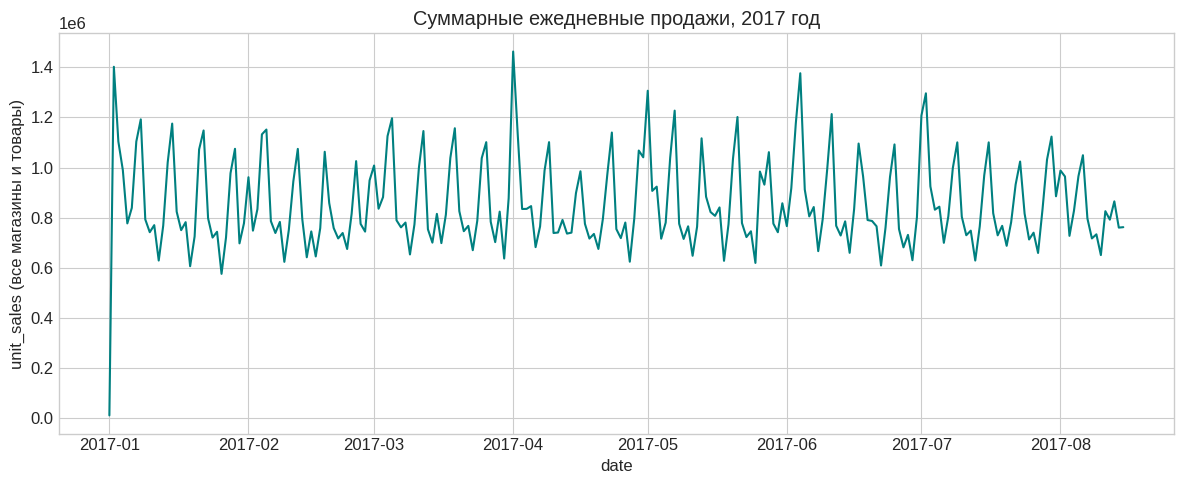

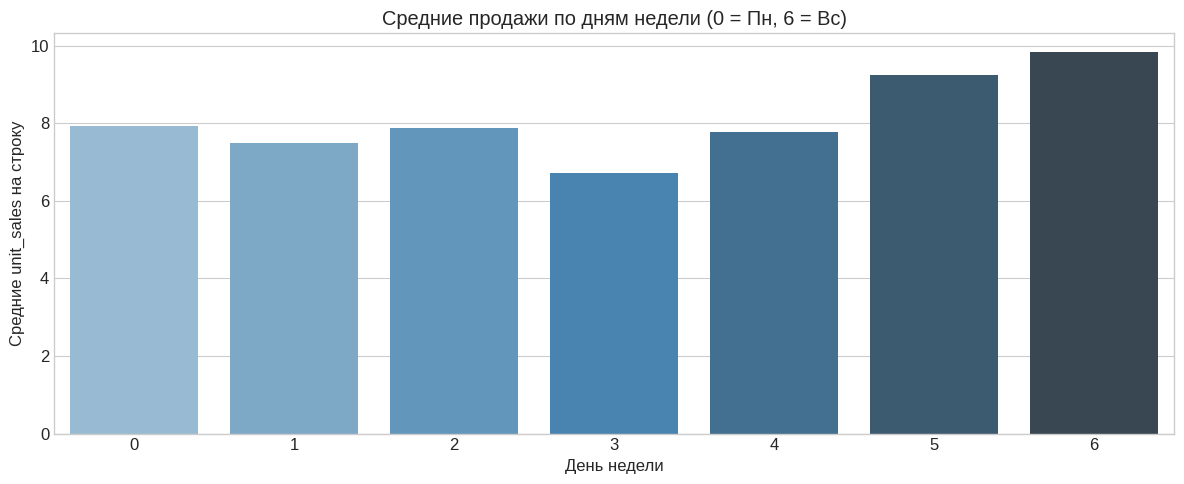


Продажи по дням недели
   dow  mean  median
0    0  7.94    4.00
1    1  7.49    3.38
2    2  7.87    3.81
3    3  6.72    3.00
4    4  7.77    3.96
5    5  9.24    4.00
6    6  9.83    4.00



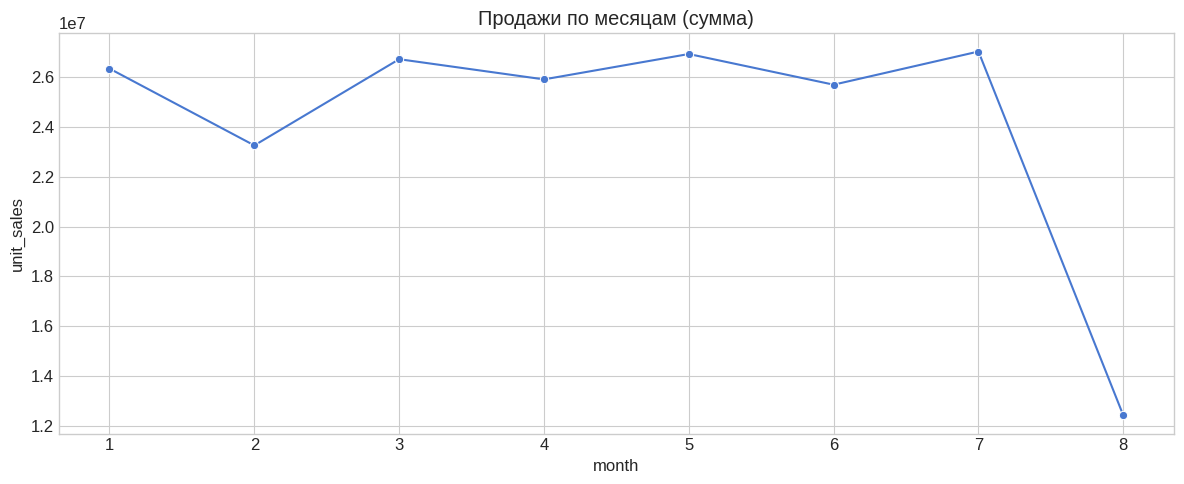

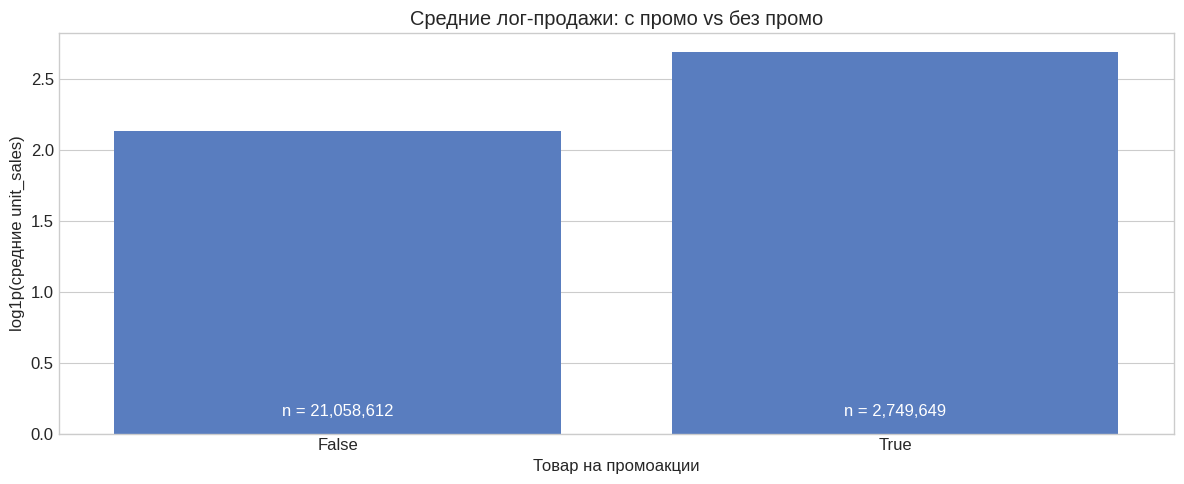


Эффект промо:
   onpromotion  mean  median     count
0        False  7.43    4.00  21058612
1         True 13.72    5.16   2749649



In [ ]:
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

train['dow'] = train['date'].dt.dayofweek # 0 = понедельник
train['weekend'] = train['dow'].isin([5,6]).astype(int)
train['day'] = train['date'].dt.day
train['month'] = train['date'].dt.month
train['is_zero'] = (train['unit_sales'] == 0).astype(int)

# Смотрим, сколько всего товаров покупается во всех магазинах
daily_sales = train.groupby('date')['unit_sales'].sum().reset_index()
plt.figure()
sns.lineplot(data=daily_sales, x='date', y='unit_sales', color='teal')
plt.title('Суммарные ежедневные продажи, 2017 год')
plt.ylabel('unit_sales (все магазины и товары)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_daily_total_sales.png', dpi=150)
plt.show()

# Сколько в среднем покупается товаров во всех магазинах
dow_sales = train.groupby('dow')['unit_sales'].agg(['mean','median','count']).reset_index()
plt.figure()
sns.barplot(data=dow_sales, x='dow', y='mean', palette='Blues_d')
plt.title('Средние продажи по дням недели (0 = Пн, 6 = Вс)')
plt.xlabel('День недели')
plt.ylabel('Средние unit_sales на строку')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_sales_by_dow.png', dpi=150)
plt.show()

print("\nПродажи по дням недели")
print(dow_sales[['dow','mean','median']])
print()

# Сумма продаж по месяцам
month_sales = train.groupby('month')['unit_sales'].sum().reset_index()
plt.figure()
sns.lineplot(data=month_sales, x='month', y='unit_sales', marker='o')
plt.title('Продажи по месяцам (сумма)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '03_sales_by_month.png', dpi=150)
plt.show()

# Эффект от промо-акций
promo_effect = train.groupby('onpromotion')['unit_sales'].agg(['mean','median','count']).reset_index()
promo_effect['mean_log'] = np.log1p(promo_effect['mean'])

plt.figure()
sns.barplot(data=promo_effect, x='onpromotion', y='mean_log')
plt.title('Средние лог-продажи: с промо vs без промо')
plt.xlabel('Товар на промоакции')
plt.ylabel('log1p(средние unit_sales)')
for i, v in enumerate(promo_effect['count']):
    plt.text(i, 0.1, f'n = {v:,}', ha='center', va='bottom', color='white')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05_promo_effect.png', dpi=150)
plt.show()

print("\nЭффект промо:")
print(promo_effect[['onpromotion','mean','median','count']])
print()

Графики сохраняем в plots/ для отчета